In [1]:
import tensorflow as tf
import numpy as np

print(tf.__version__)
print(np.__version__)

2.6.0
1.22.2


In [3]:
! mkdir -p ~/aiffel/rock_scissor_paper/scissor
! mkdir -p ~/aiffel/rock_scissor_paper/rock
! mkdir -p ~/aiffel/rock_scissor_paper/paper

! ls -l ~/aiffel/rock_scissor_paper

total 12
drwxr-xr-x 2 root root 4096 Mar  5 03:34 paper
drwxr-xr-x 2 root root 4096 Mar  5 03:34 rock
drwxr-xr-x 2 root root 4096 Mar  5 03:34 scissor


In [10]:
# 해당 폴더 안으로 들어가서 압축을 풀라는 명령어입니다.
!cd ~/aiffel/rock_scissor_paper/paper && unzip paper.zip
!cd ~/aiffel/rock_scissor_paper/rock && unzip rock.zip
!cd ~/aiffel/rock_scissor_paper/scissor && unzip scissor.zip

Archive:  paper.zip
 extracting: 0.jpg                   
 extracting: 1.jpg                   
 extracting: 2.jpg                   
 extracting: 3.jpg                   
 extracting: 4.jpg                   
 extracting: 5.jpg                   
 extracting: 6.jpg                   
 extracting: 7.jpg                   
 extracting: 8.jpg                   
 extracting: 9.jpg                   
 extracting: 10.jpg                  
 extracting: 11.jpg                  
 extracting: 12.jpg                  
 extracting: 13.jpg                  
 extracting: 14.jpg                  
 extracting: 15.jpg                  
 extracting: 16.jpg                  
 extracting: 17.jpg                  
 extracting: 18.jpg                  
 extracting: 19.jpg                  
 extracting: 20.jpg                  
 extracting: 21.jpg                  
 extracting: 22.jpg                  
 extracting: 23.jpg                  
 extracting: 24.jpg                  
 extracting: 25.jpg           

In [2]:
from PIL import Image 
import glob
import os

print("PIL 라이브러리 import 완료!")

PIL 라이브러리 import 완료!


In [102]:
def resize_images(img_path):
	images=glob.glob(img_path + "/*.jpg")  
    
	print(len(images), " images to be resized.")

    # 파일마다 모두 28x28 사이즈로 바꾸어 저장합니다.
	target_size=(128,128)
	for img in images:
		old_img=Image.open(img)
		new_img=old_img.resize(target_size,Image.ANTIALIAS)
		new_img.save(img, "JPEG")
    
	print(len(images), " images resized.")
	
# 가위 이미지가 저장된 디렉토리 아래의 모든 jpg 파일을 읽어들여서
image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/scissor"
resize_images(image_dir_path)

print("가위 이미지 resize 완료!")

131  images to be resized.
131  images resized.
가위 이미지 resize 완료!


In [103]:
image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/rock"
resize_images(image_dir_path)

119  images to be resized.
119  images resized.


In [104]:
image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper/paper"
resize_images(image_dir_path)

117  images to be resized.
117  images resized.


In [60]:
import numpy as np

def load_data(img_path, number_of_data=367):  # 가위바위보 이미지 개수 총합에 주의하세요.
    # 가위 : 0, 바위 : 1, 보 : 2
    img_size=128
    color=3
    #이미지 데이터와 라벨(가위 : 0, 바위 : 1, 보 : 2) 데이터를 담을 행렬(matrix) 영역을 생성합니다.
    imgs=np.zeros(number_of_data*img_size*img_size*color,dtype=np.int32).reshape(number_of_data,img_size,img_size,color)
    labels=np.zeros(number_of_data,dtype=np.int32)

    idx=0
    for file in glob.iglob(img_path+'/scissor/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=0   # 가위 : 0
        idx=idx+1

    for file in glob.iglob(img_path+'/rock/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=1   # 바위 : 1
        idx=idx+1  
    
    for file in glob.iglob(img_path+'/paper/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=2   # 보 : 2
        idx=idx+1
        
    print("학습데이터(x_train)의 이미지 개수는", idx,"입니다.")
    return imgs, labels

image_dir_path = os.getenv("HOME") + "/aiffel/rock_scissor_paper"
(x_train, y_train)=load_data(image_dir_path)
x_train_norm = x_train/255.0   # 입력은 0~1 사이의 값으로 정규화

print("x_train shape: {}".format(x_train.shape))
print("y_train shape: {}".format(y_train.shape))

학습데이터(x_train)의 이미지 개수는 367 입니다.
x_train shape: (367, 128, 128, 3)
y_train shape: (367,)


In [61]:
x_train_norm.shape

(367, 128, 128, 3)

라벨:  0


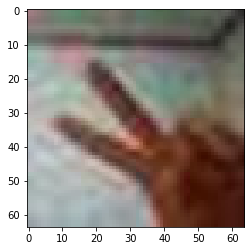

In [46]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0])
print('라벨: ', y_train[0])

In [8]:
from tensorflow import keras

In [69]:
#model
n_channel_1=64
n_channel_2=128
n_dense=64
n_train_epoch=12

model=keras.models.Sequential()
model.add(keras.layers.Conv2D(n_channel_1, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPool2D(2,2))
model.add(keras.layers.Conv2D(n_channel_2, (3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2,2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(n_dense, activation='relu'))
model.add(keras.layers.Dense(3, activation='softmax'))

model.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_8 (Conv2D)            (None, 126, 126, 64)      1792      
_________________________________________________________________
max_pooling2d_8 (MaxPooling2 (None, 63, 63, 64)        0         
_________________________________________________________________
conv2d_9 (Conv2D)            (None, 61, 61, 128)       73856     
_________________________________________________________________
max_pooling2d_9 (MaxPooling2 (None, 30, 30, 128)       0         
_________________________________________________________________
flatten_4 (Flatten)          (None, 115200)            0         
_________________________________________________________________
dense_8 (Dense)              (None, 64)                7372864   
_________________________________________________________________
dense_9 (Dense)              (None, 3)                

In [70]:
model.compile(optimizer='adam', 
              #가중치 업데이트 결정 알고리즘. 
              #adam은 현재 딥러닝에서 가장 많이 쓰임
             loss='sparse_categorical_crossentropy', 
              #오차 최소화하는 방식으로 모델 학습됨
             metrics=['accuracy'])# 채점기준 = accuracy

model.fit(x_train_norm, y_train, epochs=n_train_epoch)
#epochs는 학습을 10번 반복하는 것

Epoch 1/12
12/12 [==============================] - 34s 3s/step - loss: 1.6128 - accuracy: 0.3569
Epoch 2/12
12/12 [==============================] - 33s 3s/step - loss: 0.8607 - accuracy: 0.6267
Epoch 3/12
12/12 [==============================] - 33s 3s/step - loss: 0.5264 - accuracy: 0.7766
Epoch 4/12
12/12 [==============================] - 33s 3s/step - loss: 0.4141 - accuracy: 0.8256
Epoch 5/12
12/12 [==============================] - 33s 3s/step - loss: 0.2526 - accuracy: 0.9210
Epoch 6/12
12/12 [==============================] - 34s 3s/step - loss: 0.1601 - accuracy: 0.9482
Epoch 7/12
12/12 [==============================] - 33s 3s/step - loss: 0.1055 - accuracy: 0.9673
Epoch 8/12
12/12 [==============================] - 33s 3s/step - loss: 0.0709 - accuracy: 0.9837
Epoch 9/12
12/12 [==============================] - 33s 3s/step - loss: 0.0374 - accuracy: 0.9891
Epoch 10/12
12/12 [==============================] - 34s 3s/step - loss: 0.0218 - accuracy: 0.9973
Epoch 11/12
12/12 [

In [71]:
predicted_result = model.predict(x_train_norm)  # model이 추론한 확률값. 
predicted_labels = np.argmax(predicted_result, axis=1)

idx=0 

In [72]:
import random
wrong_predict_list=[]
for i, _ in enumerate(predicted_labels):
    # i번째 test_labels과 y_test이 다른 경우만 모아 봅시다. 
    if predicted_labels[i] != y_train[i]:
        wrong_predict_list.append(i)

# wrong_predict_list 에서 랜덤하게 5개만 뽑아봅시다.
samples = random.choices(population=wrong_predict_list, k=5)

for n in samples:
    print("예측확률분포: " + str(predicted_result[n]))
    print("라벨: " + str(y_train[n]) + ", 예측결과: " + str(predicted_labels[n]))
    plt.imshow(x_train_norm[n], cmap=plt.cm.binary)
    plt.show()

IndexError: list index out of range

<내 데이터셋으로 학습해본 결과>

화질이 굉장히 깨진다....
-> 화질을 개선해봄
 
28*28일때 -> 정확도 0.85

64 x64 ->  0.96

128x128 & 하이퍼파라미터(n_channel_1 = 64
n_channel_2 = 128
n_dense = 64
n_train_epoch = 20) -> 1.0(과대적합...?)

## 가현님 dataset 사용

In [13]:
!cd ~/aiffel/gh_data/paper && unzip paper.zip
!cd ~/aiffel/gh_data/rock && unzip rock.zip
!cd ~/aiffel/gh_data/scissor && unzip scissor.zip

Archive:  paper.zip
replace 0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C
Archive:  rock.zip
replace 0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C
Archive:  scissor.zip
replace 0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [112]:
image_dir_path = os.getenv("HOME") + "/aiffel/gh_data/paper"
resize_images(image_dir_path)

print("가위 이미지 resize 완료!")

image_dir_path = os.getenv("HOME") + "/aiffel/gh_data/rock"
resize_images(image_dir_path)

print("주먹 이미지 resize 완료!")

image_dir_path = os.getenv("HOME") + "/aiffel/gh_data/scissor"
resize_images(image_dir_path)

print("가위 이미지 scissor 완료!")

100  images to be resized.
100  images resized.
가위 이미지 resize 완료!
100  images to be resized.
100  images resized.
주먹 이미지 resize 완료!
100  images to be resized.
100  images resized.
가위 이미지 scissor 완료!


In [113]:
import numpy as np

def load_data(img_path, number_of_data=300):  # 가위바위보 이미지 개수 총합에 주의하세요.
    # 가위 : 0, 바위 : 1, 보 : 2
    img_size=128
    color=3
    #이미지 데이터와 라벨(가위 : 0, 바위 : 1, 보 : 2) 데이터를 담을 행렬(matrix) 영역을 생성합니다.
    imgs=np.zeros(number_of_data*img_size*img_size*color,dtype=np.int32).reshape(number_of_data,img_size,img_size,color)
    labels=np.zeros(number_of_data,dtype=np.int32)

    idx=0
    for file in glob.iglob(img_path+'/scissor/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=0   # 가위 : 0
        idx=idx+1

    for file in glob.iglob(img_path+'/rock/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=1   # 바위 : 1
        idx=idx+1  
    
    for file in glob.iglob(img_path+'/paper/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=2   # 보 : 2
        idx=idx+1
        
    print("학습데이터(x_train)의 이미지 개수는", idx,"입니다.")
    return imgs, labels

In [114]:
image_dir_path = os.getenv("HOME") + "/aiffel/gh_data"
(x_test, y_test)=load_data(image_dir_path)
x_test_norm = x_test/255.0   # 입력은 0~1 사이의 값으로 정규화

print("x_test shape: {}".format(x_test.shape))
print("y_test shape: {}".format(y_test.shape))

학습데이터(x_train)의 이미지 개수는 300 입니다.
x_test shape: (300, 128, 128, 3)
y_test shape: (300,)


In [76]:
test_loss, test_accuracy = model.evaluate(x_test_norm, y_test, verbose=2)
print("test_loss: {} ".format(test_loss))
print("test_accuracy: {}".format(test_accuracy))

10/10 - 8s - loss: 3.8834 - accuracy: 0.3500
test_loss: 3.8833837509155273 
test_accuracy: 0.3499999940395355


In [100]:
predicted_result = model.predict(x_test_norm)  # model이 추론한 확률값. 
predicted_labels = np.argmax(predicted_result, axis=1)

idx=0 

예측확률분포: [1.4468616e-04 5.1677828e-03 9.9468756e-01]
라벨: 1, 예측결과: 2


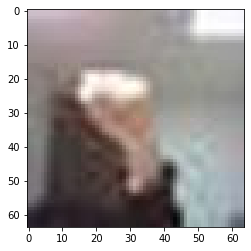

예측확률분포: [1.8853569e-04 8.8351626e-08 9.9981135e-01]
라벨: 0, 예측결과: 2


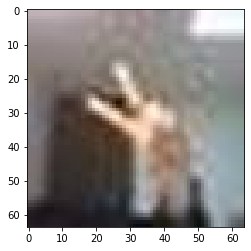

예측확률분포: [2.1351070e-06 1.5120415e-07 9.9999774e-01]
라벨: 1, 예측결과: 2


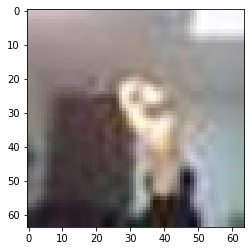

예측확률분포: [8.4315501e-03 7.6656252e-06 9.9156076e-01]
라벨: 0, 예측결과: 2


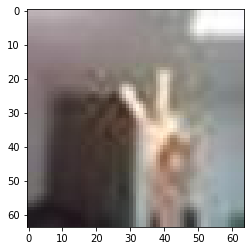

예측확률분포: [7.4787093e-03 2.2502168e-06 9.9251902e-01]
라벨: 0, 예측결과: 2


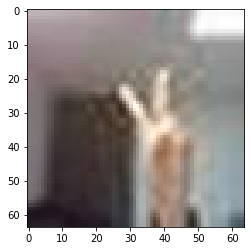

In [101]:
import random
wrong_predict_list=[]
for i, _ in enumerate(predicted_labels):
    # i번째 test_labels과 y_test이 다른 경우만 모아 봅시다. 
    if predicted_labels[i] != y_test[i]:
        wrong_predict_list.append(i)

# wrong_predict_list 에서 랜덤하게 5개만 뽑아봅시다.
samples = random.choices(population=wrong_predict_list, k=5)

for n in samples:
    print("예측확률분포: " + str(predicted_result[n]))
    print("라벨: " + str(y_test[n]) + ", 예측결과: " + str(predicted_labels[n]))
    plt.imshow(x_test_norm[n], cmap=plt.cm.binary)
    plt.show()

가현님 데이터 돌렸을때 0.30(28*28)

64 x 64로 바꾸니 오히려 떨어짐 -. 0.183

128*128 + 하이퍼파라미터 튜닝 -> 0.3499

## 수민님 데이터셋을 제 데이터셋에 추가

In [83]:
!cd ~/aiffel/sm_data/paper && unzip paper.zip
!cd ~/aiffel/sm_data/rock && unzip rock.zip
!cd ~/aiffel/sm_data/scissor && unzip scissor.zip

Archive:  paper.zip
 extracting: 0.jpg                   
 extracting: 1.jpg                   
 extracting: 2.jpg                   
 extracting: 3.jpg                   
 extracting: 4.jpg                   
 extracting: 5.jpg                   
 extracting: 6.jpg                   
 extracting: 7.jpg                   
 extracting: 8.jpg                   
 extracting: 9.jpg                   
 extracting: 10.jpg                  
 extracting: 11.jpg                  
 extracting: 12.jpg                  
 extracting: 13.jpg                  
 extracting: 14.jpg                  
 extracting: 15.jpg                  
 extracting: 16.jpg                  
 extracting: 17.jpg                  
 extracting: 18.jpg                  
 extracting: 19.jpg                  
 extracting: 20.jpg                  
 extracting: 21.jpg                  
 extracting: 22.jpg                  
 extracting: 23.jpg                  
 extracting: 24.jpg                  
 extracting: 25.jpg           

In [105]:
image_dir_path = os.getenv("HOME") + "/aiffel/sm_data/scissor"
resize_images(image_dir_path)

print("가위 이미지 resize 완료!")

image_dir_path = os.getenv("HOME") + "/aiffel/sm_data/rock"
resize_images(image_dir_path)

print("바위 이미지 resize 완료!")

image_dir_path = os.getenv("HOME") + "/aiffel/sm_data/paper"
resize_images(image_dir_path)

print("보 이미지 resize 완료!")

113  images to be resized.
113  images resized.
가위 이미지 resize 완료!
121  images to be resized.
121  images resized.
바위 이미지 resize 완료!
102  images to be resized.
102  images resized.
보 이미지 resize 완료!


In [106]:
import os
import glob
import numpy as np
from PIL import Image

def load_data(img_paths, number_of_data=703):  # img_path -> img_paths (리스트임을 명시)
    img_size=128
    color=3
    
    # 이미지 데이터와 라벨 데이터를 담을 행렬 생성
    imgs=np.zeros(number_of_data*img_size*img_size*color,dtype=np.int32).reshape(number_of_data,img_size,img_size,color)
    labels=np.zeros(number_of_data,dtype=np.int32)

    idx=0
    # 핵심 수정 부분: 전달받은 리스트(img_paths)에서 경로를 하나씩 꺼냅니다.
    for path in img_paths:
        for file in glob.iglob(path+'/scissor/*.jpg'):
            img = np.array(Image.open(file),dtype=np.int32)
            imgs[idx,:,:,:]=img
            labels[idx]=0   # 가위 : 0
            idx += 1

        for file in glob.iglob(path+'/rock/*.jpg'):
            img = np.array(Image.open(file),dtype=np.int32)
            imgs[idx,:,:,:]=img
            labels[idx]=1   # 바위 : 1
            idx += 1  
        
        for file in glob.iglob(path+'/paper/*.jpg'):
            img = np.array(Image.open(file),dtype=np.int32)
            imgs[idx,:,:,:]=img
            labels[idx]=2   # 보 : 2
            idx += 1
            
    print("학습데이터(x_train)의 이미지 개수는", idx,"입니다.")
    return imgs, labels

path1 = os.getenv("HOME") + "/aiffel/rock_scissor_paper"
path2 = os.getenv("HOME") + "/aiffel/sm_data"

# 리스트 형태로 전달
(x_train, y_train) = load_data([path1, path2])
x_train_norm = x_train/255.0   # 입력은 0~1 사이의 값으로 정규화

print("x_train shape: {}".format(x_train.shape))
print("y_train shape: {}".format(y_train.shape))

학습데이터(x_train)의 이미지 개수는 703 입니다.
x_train shape: (703, 128, 128, 3)
y_train shape: (703,)


In [107]:
#model
n_channel_1=64
n_channel_2=128
n_dense=64
n_train_epoch=12

model=keras.models.Sequential()
model.add(keras.layers.Conv2D(n_channel_1, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPool2D(2,2))
model.add(keras.layers.Conv2D(n_channel_2, (3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2,2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(n_dense, activation='relu'))
model.add(keras.layers.Dense(3, activation='softmax'))

model.summary()

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_12 (Conv2D)           (None, 126, 126, 64)      1792      
_________________________________________________________________
max_pooling2d_12 (MaxPooling (None, 63, 63, 64)        0         
_________________________________________________________________
conv2d_13 (Conv2D)           (None, 61, 61, 128)       73856     
_________________________________________________________________
max_pooling2d_13 (MaxPooling (None, 30, 30, 128)       0         
_________________________________________________________________
flatten_6 (Flatten)          (None, 115200)            0         
_________________________________________________________________
dense_12 (Dense)             (None, 64)                7372864   
_________________________________________________________________
dense_13 (Dense)             (None, 3)                

In [108]:
model.compile(optimizer='adam', 
              #가중치 업데이트 결정 알고리즘. 
              #adam은 현재 딥러닝에서 가장 많이 쓰임
             loss='sparse_categorical_crossentropy', 
              #오차 최소화하는 방식으로 모델 학습됨
             metrics=['accuracy'])# 채점기준 = accuracy

model.fit(x_train_norm, y_train, epochs=n_train_epoch)

Epoch 1/12
22/22 [==============================] - 63s 3s/step - loss: 0.6597 - accuracy: 0.7027
Epoch 4/12
22/22 [==============================] - 63s 3s/step - loss: 0.4911 - accuracy: 0.7966
Epoch 5/12
22/22 [==============================] - 63s 3s/step - loss: 0.3109 - accuracy: 0.8919
Epoch 6/12
22/22 [==============================] - 64s 3s/step - loss: 0.2213 - accuracy: 0.9260
Epoch 7/12
22/22 [==============================] - 63s 3s/step - loss: 0.1268 - accuracy: 0.9687
Epoch 8/12
22/22 [==============================] - 63s 3s/step - loss: 0.0896 - accuracy: 0.9716
Epoch 9/12
22/22 [==============================] - 63s 3s/step - loss: 0.0538 - accuracy: 0.9915
Epoch 10/12
22/22 [==============================] - 65s 3s/step - loss: 0.0326 - accuracy: 0.9972
Epoch 11/12
22/22 [==============================] - 64s 3s/step - loss: 0.0153 - accuracy: 0.9986
Epoch 12/12
22/22 [==============================] - 63s 3s/step - loss: 0.0076 - accuracy: 1.0000


In [99]:
test_loss, test_accuracy = model.evaluate(x_test_norm, y_test, verbose=2)
print("test_loss: {} ".format(test_loss))
print("test_accuracy: {}".format(test_accuracy))

10/10 - 1s - loss: 5.4670 - accuracy: 0.2967
test_loss: 5.466981410980225 
test_accuracy: 0.2966666519641876


내 데이터셋 + 수민님 데이터셋 -> 가현님 데이터셋(64*64) + 위에서 쓴 하이퍼파라미터 값 동일(epoch만 12로 -> 시간 오래 걸림 이슈로)
=> 0.2967

In [115]:
test_loss, test_accuracy = model.evaluate(x_test_norm, y_test, verbose=2)
print("test_loss: {} ".format(test_loss))
print("test_accuracy: {}".format(test_accuracy))

10/10 - 8s - loss: 5.3022 - accuracy: 0.3633
test_loss: 5.302179336547852 
test_accuracy: 0.3633333444595337


내 데이터셋 + 수민님 데이터셋 -> 가현님 데이터셋(128*128) + 위에서 쓴 하이퍼파라미터 값 동일(epoch만 12로 -> 시간 오래 걸림 이슈로)
=> 0.3633

In [116]:
predicted_result = model.predict(x_test_norm)  # model이 추론한 확률값. 
predicted_labels = np.argmax(predicted_result, axis=1)

idx=0 

예측확률분포: [0.4533338  0.02867093 0.5179953 ]
라벨: 0, 예측결과: 2


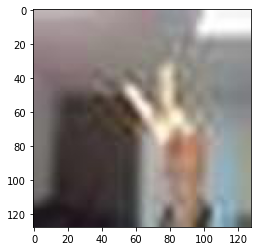

예측확률분포: [0.28284147 0.00569651 0.711462  ]
라벨: 0, 예측결과: 2


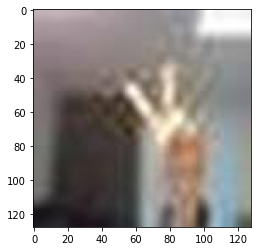

예측확률분포: [7.5518942e-09 2.3457782e-04 9.9976546e-01]
라벨: 1, 예측결과: 2


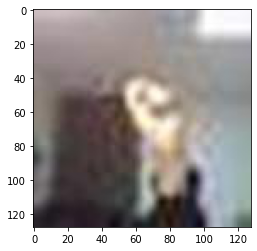

예측확률분포: [1.4596782e-05 2.0097115e-04 9.9978441e-01]
라벨: 0, 예측결과: 2


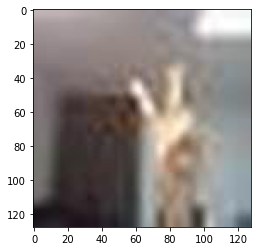

예측확률분포: [6.6142576e-07 6.9381982e-01 3.0617949e-01]
라벨: 2, 예측결과: 1


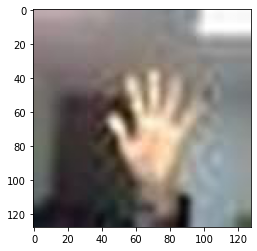

In [117]:
import random
wrong_predict_list=[]
for i, _ in enumerate(predicted_labels):
    # i번째 test_labels과 y_test이 다른 경우만 모아 봅시다. 
    if predicted_labels[i] != y_test[i]:
        wrong_predict_list.append(i)

# wrong_predict_list 에서 랜덤하게 5개만 뽑아봅시다.
samples = random.choices(population=wrong_predict_list, k=5)

for n in samples:
    print("예측확률분포: " + str(predicted_result[n]))
    print("라벨: " + str(y_test[n]) + ", 예측결과: " + str(predicted_labels[n]))
    plt.imshow(x_test_norm[n], cmap=plt.cm.binary)
    plt.show()

In [124]:
len(wrong_predict_list)

191

결론 :
1. 해상도를 높임, 데이터 수 추가(다른 사람거), 하이퍼파라미터 튜닝-> 정확도가 좋아지긴 함
2. 그러나 여전히 300개 중 191개는 틀림(0.36)
3. 현재는 학습 데이터는 1.0의 정확도가 나오고 test 데이터에선 0.3정도
    -> 과적합이라고 의심 가능

예상 개선방안
1. 다른 사람의 데이터셋 더 추가
2. 드롭아웃 층 추가(모델이 배경이나 특정 픽셀에 집착하지 않고 손의 전체적 형태에 집중할 수 있도록하는 방안)
3. 데이터 증강 적용(ImageDataGenerator를 사용해서 이미지를 학습할때마다 살짝 회전시키고, 좌우로 이동시키고, 확대/축소함)-> 좀 더 다양한 사람의 손을 보는것과 같은 효과 부여